# BinX Week 07 — Day 4: Attention & Transformers (Colab GPU Edition)

| Field | Value |
|:------|:------|
| **Phase** | Phase 3 — Deep Learning & Applied Project |
| **Sprint** | Sprint 2 (Weeks 6–9) |
| **Day** | Day 4 of 5 |
| **Dataset** | 330K Arabic Sentiment Reviews (binary: positive / negative) |
| **Model** | Pre-trained Arabic BERT (AraBERT v2) via Hugging Face |
| **Notebook** | `BinX_Week_07/Day4/Attention_Transformers.ipynb` |
| **Runtime** | Google Colab with T4 GPU (recommended) |

> **⚡ Colab Optimised** — This notebook is refactored for GPU-accelerated training
> with FP16 mixed precision, Hugging Face `Trainer`, and automatic checkpoint
> persistence to Google Drive.

---
## 1. From RNNs/LSTMs to Attention — Why Transformers?

### The Limitation of Recurrence

In Day 3, we learned that RNNs and LSTMs process sequences **one token at a time**, carrying a hidden state that summarizes all previous tokens. This design has fundamental limitations:

1. **Sequential bottleneck**: Tokens must be processed in order. Token 100 cannot be processed until tokens 1–99 are complete. This prevents parallelization across the sequence.
2. **Vanishing gradients over long distances**: Even with LSTM gates, information from early tokens gradually degrades as it passes through many time steps. A sentiment word at position 5 may have diminished influence by the time we reach position 500.
3. **Fixed-length bottleneck**: The hidden state is a fixed-size vector that must compress the entire sequence. For long texts, this creates an information bottleneck.

### The Attention Solution

The **attention mechanism** (Bahdanau et al., 2014; Vaswani et al., 2017 — "Attention Is All You Need") solves these problems by allowing **every token to directly attend to every other token** in the sequence, regardless of distance.

**Key advantages:**
- **Parallel processing**: All positions can be computed simultaneously — no sequential dependency.
- **Direct long-range connections**: Token 1 can directly influence token 500 without passing through 499 intermediate steps.
- **Dynamic relevance**: The model learns which tokens are most relevant to each other, adapting attention weights to the input.

### How Attention Differs from RNN Memory

| Aspect | RNN/LSTM | Transformer (Self-Attention) |
|:-------|:---------|:-----------------------------|
| **Processing** | Sequential (one token at a time) | Parallel (all tokens simultaneously) |
| **Memory mechanism** | Hidden state passed step-by-step | Query-Key-Value attention scores |
| **Long-range dependencies** | Degrade over distance | Direct connection between any two positions |
| **Parallelization** | Inherently sequential | Fully parallelizable |
| **Information bottleneck** | Fixed-size hidden state | Each token gets its own context-aware representation |
| **Computational complexity** | O(n) per step, O(n²) total | O(n²) but parallelizable (GPU-friendly) |

---
## 2. The Transformer Architecture — Conceptual Overview

The Transformer (Vaswani et al., 2017) consists of the following key components:

### 2.1 Embeddings

Each input token is mapped to a dense vector (embedding). For pre-trained models like BERT, these embeddings are learned during pre-training on massive text corpora.

### 2.2 Self-Attention

Self-attention computes three vectors for each token:
- **Query (Q)**: "What am I looking for?"
- **Key (K)**: "What do I contain?"
- **Value (V)**: "What information do I provide?"

Attention scores are computed as: `Attention(Q, K, V) = softmax(QK^T / √d_k) V`

This allows each token to dynamically weigh the relevance of all other tokens.

### 2.3 Multi-Head Attention

Instead of a single attention function, the Transformer uses multiple "heads" that attend to different aspects of the relationship between tokens (e.g., syntactic vs. semantic relationships).

### 2.4 Feed-Forward Layers
After attention, each token's representation passes through a feed-forward neural network for further transformation.

### 2.5 Positional Encoding

Since self-attention is permutation-invariant (it doesn't inherently know token order), **positional encodings** are added to embeddings to inject position information. This tells the model that "the cat sat" is different from "sat the cat."

### 2.6 Encoder-Decoder Structure

The original Transformer has both an encoder (processes input) and decoder (generates output). For **classification tasks**, we typically use only the **encoder** — this is what BERT does.

### Why Pre-trained Transformers Work for Classification

Models like BERT are pre-trained on massive text corpora (e.g., Wikipedia + BookCorpus) using:
- **Masked Language Modeling (MLM)**: Predict missing tokens → learns deep contextual representations
- **Next Sentence Prediction (NSP)**: Learn sentence relationships

For classification, we add a simple classification head on top of the pre-trained encoder and fine-tune on our task. This leverages the vast linguistic knowledge already encoded in the model.

---
## 3. Environment Setup & GPU Diagnostics (Colab)

> **Runtime requirement:** `Runtime → Change runtime type → T4 GPU`
>
> The cells below install dependencies, verify GPU availability, and mount
> Google Drive so model checkpoints survive session timeouts.

In [ ]:
# ============================================================
# 1. COLAB ENVIRONMENT SETUP
#    Run this cell FIRST.  It installs packages, checks for a
#    GPU, and mounts Google Drive for checkpoint persistence.
# ============================================================

# --- Install required packages (safe to re-run) ---------------------------
%pip install -q transformers datasets accelerate evaluate torchmetrics

# --- GPU diagnostic -------------------------------------------------------
import torch, subprocess, sys

print("=" * 60)
print("GPU DIAGNOSTICS")
print("=" * 60)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU detected : {gpu_name}")
    print(f"  VRAM         : {gpu_mem:.1f} GB")
else:
    print("  ⚠  No GPU detected — training will run on CPU (very slow).")
    print("     Go to  Runtime → Change runtime type → T4 GPU")
print("=" * 60)

# --- Mount Google Drive ----------------------------------------------------
try:
    from google.colab import drive          # noqa: F401  (only on Colab)
    drive.mount("/content/drive")
    DRIVE_MOUNTED = True
    print("\n[OK] Google Drive mounted at /content/drive")
except ImportError:
    DRIVE_MOUNTED = False
    print("\n[INFO] Not running on Colab — Drive mount skipped.")
    print("       Checkpoints will be saved locally.")

GPU DIAGNOSTICS
  GPU detected : Tesla T4
  VRAM         : 15.6 GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[OK] Google Drive mounted at /content/drive


In [ ]:
# --- Core Libraries --------------------------------------------------------
import json
import os
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# --- PyTorch ---------------------------------------------------------------
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset

# --- Hugging Face -----------------------------------------------------------
import evaluate  # HF evaluate library
import transformers as _tf
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup,
)

# --- Scikit-learn -----------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

# --- Reproducibility --------------------------------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Plot Defaults (matching project conventions) ---------------------------
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

# --- Device ------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("ENVIRONMENT")
print("=" * 60)
print(f"  PyTorch version  : {torch.__version__}")
print(f"  Transformers ver : {_tf.__version__}")
print(f"  NumPy version    : {np.__version__}")
print(f"  Pandas version   : {pd.__version__}")
print(f"  Device           : {DEVICE}")

if DEVICE.type == "cuda":
    print(f"  GPU              : {torch.cuda.get_device_name(0)}")
    print(
        f"  VRAM             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB"
    )

print("=" * 60)
print(f"\n  Random seed set to {SEED} for reproducibility.")
print("  [OK] All libraries loaded successfully.")

ENVIRONMENT
  PyTorch version  : 2.11.0+cu128
  Transformers ver : 5.16.1
  NumPy version    : 2.1.3
  Pandas version   : 2.2.3
  Device           : cuda
  GPU              : Tesla T4
  VRAM             : 15.6 GB

  Random seed set to 42 for reproducibility.
  [OK] All libraries loaded successfully.


---
## 4. Dataset Overview — 330K Arabic Sentiment Reviews

### Source

The dataset is the **330K Arabic Sentiment Reviews Dataset** from Kaggle:
- Kaggle: `https://www.kaggle.com/datasets/abdallaellaithy/330k-arabic-sentiment-reviews`
- Local path: `Data/ALP_dataset/arabic_sentiment_reviews.csv`

### Task

**Binary sentiment classification**: given an Arabic product review, predict whether it is positive (1) or negative (0).

### Why This Dataset?

1. It is a **text-based** task — the natural domain for Transformers.
2. Arabic is a morphologically rich language where contextual understanding (which Transformers excel at) is critical.
3. The dataset is large enough to demonstrate Transformer capabilities but requires careful sampling for practical training.

In [ ]:
# --- Dataset Path (Colab-aware) -------------------------------------------
# On Colab the data is expected in  /content/drive/MyDrive/Data/ALP_dataset/
# Locally it lives at  ../../Data/ALP_dataset/

COLAB_DATA = "/content/drive/MyDrive/ALP_dataset/arabic_sentiment_reviews.csv"
LOCAL_DATA = os.path.join("..", "..", "Data", "ALP_dataset", "arabic_sentiment_reviews.csv")

if os.path.exists(COLAB_DATA):
    DATA_PATH = COLAB_DATA
elif os.path.exists(LOCAL_DATA):
    DATA_PATH = LOCAL_DATA
else:
    raise FileNotFoundError(
        f"Dataset not found.\n"
        f"  Colab path : {COLAB_DATA}\n"
        f"  Local path : {LOCAL_DATA}\n"
        f"Upload the CSV to Google Drive → Data/ALP_dataset/ before running."
    )

print("=" * 60)
print("DATASET DISCOVERY")
print("=" * 60)
size_mb = os.path.getsize(DATA_PATH) / (1024 * 1024)
print(f"  File   : {DATA_PATH}")
print(f"  Size   : {size_mb:.1f} MB")
print("=" * 60)

DATASET DISCOVERY
  File   : /content/drive/MyDrive/ALP_dataset/arabic_sentiment_reviews.csv
  Size   : 202.4 MB


---
## 5. Data Validation & Preparation

Before modeling, we inspect the actual CSV to determine:
- Number of rows and columns
- Column names and data types
- Missing values
- Label distribution
- Text length distribution
- Any unexpected formatting issues

In [ ]:
# --- Load Data ---
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("DATASET INSPECTION")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Data types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print("=" * 60)

DATASET INSPECTION
Shape: (330000, 2)
Columns: ['label', 'content']
Data types:
label       int64
content    object
dtype: object

First 5 rows:
   label                                            content
0      1  النعال المريحة: أرتدي هذه النعال كثيرًا!فهي دا...
1      1  منتج جميل ، خدمة سيئة: لقد اشتريت زوجًا من الن...
2      1  جيد للأشياء الصغيرة: هذا يعمل بشكل جيد لالتقاط...
3      0  واهية للغاية: flimsyif للغاية ، فأنت تشتريه ، ...
4      1  Pop for Girls and Girly Boys ، والأشخاص الذين ...

Missing values:
label      0
content    0
dtype: int64

Duplicate rows: 32


LABEL DISTRIBUTION
  Negative (0): 163,147 samples (49.4%)
  Positive (1): 166,853 samples (50.6%)
  Total: 330,000 samples

Imbalance ratio: 1.02x


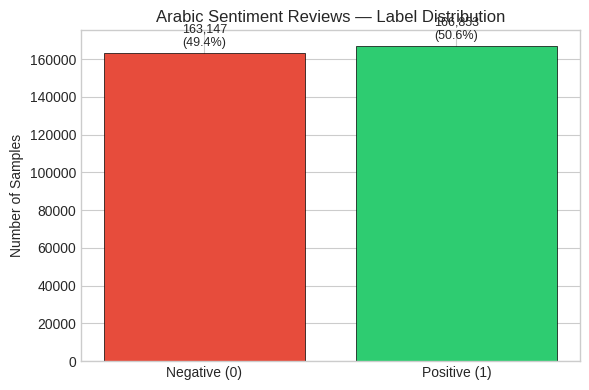

In [ ]:
# --- Label Distribution ---
print("=" * 60)
print("LABEL DISTRIBUTION")
print("=" * 60)
label_counts = df['label'].value_counts().sort_index()
label_pct = df['label'].value_counts(normalize=True).sort_index() * 100

for label, count, pct in zip(label_counts.index, label_counts.values, label_pct.values):
    label_name = "Negative (0)" if label == 0 else "Positive (1)"
    print(f"  {label_name}: {count:,} samples ({pct:.1f}%)")
print(f"  Total: {len(df):,} samples")
print(f"\nImbalance ratio: {label_counts.max() / label_counts.min():.2f}x")
print("=" * 60)

# --- Plot label distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#e74c3c', '#2ecc71']
bars = ax.bar(['Negative (0)', 'Positive (1)'], label_counts.values, color=colors, edgecolor='black', linewidth=0.5)
for bar, count, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2000,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Arabic Sentiment Reviews — Label Distribution')
ax.set_ylabel('Number of Samples')
plt.tight_layout()
plt.show()

TEXT LENGTH STATISTICS
       text_length_chars  text_length_words
count           330000.0           330000.0
mean               362.4               64.7
std                197.9               35.7
min                  2.0                1.0
25%                196.0               35.0
50%                325.0               58.0
75%                499.0               89.0
max               1035.0              197.0


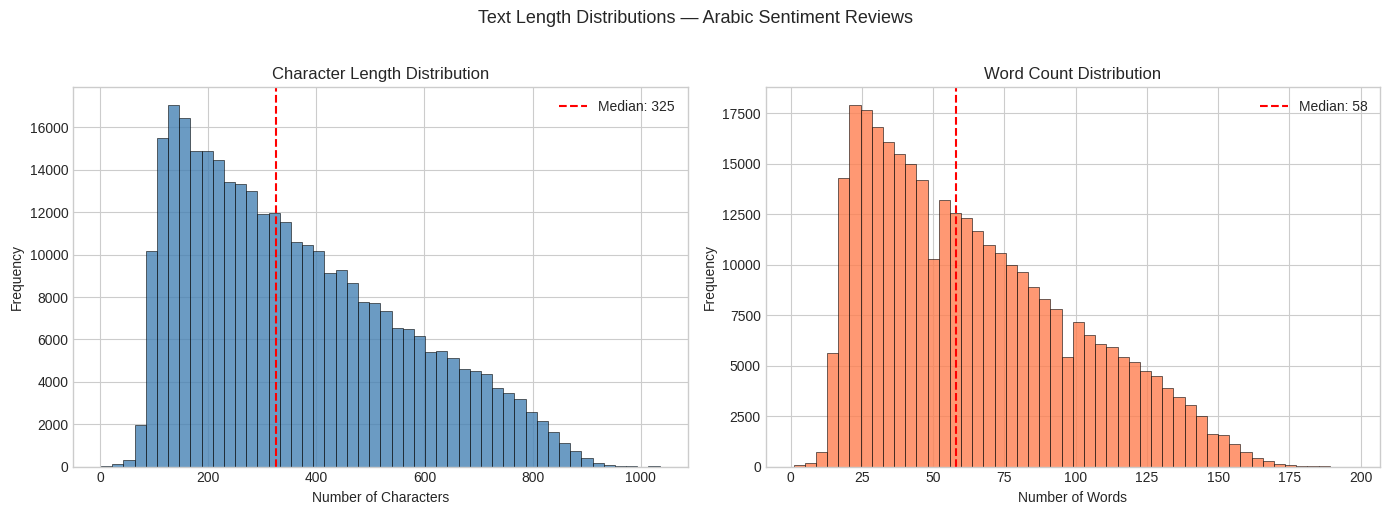

In [ ]:
# --- Text Length Analysis ---
# Compute character-level and word-level text lengths
df['text_length_chars'] = df['content'].astype(str).str.len()
df['text_length_words'] = df['content'].astype(str).str.split().str.len()

print("=" * 60)
print("TEXT LENGTH STATISTICS")
print("=" * 60)
print(df[['text_length_chars', 'text_length_words']].describe().round(1))
print("=" * 60)

# --- Plot text length distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_length_chars'], bins=50, color='steelblue', edgecolor='black', linewidth=0.5, alpha=0.8)
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['text_length_chars'].median(), color='red', linestyle='--', label=f"Median: {df['text_length_chars'].median():.0f}")
axes[0].legend()

axes[1].hist(df['text_length_words'], bins=50, color='coral', edgecolor='black', linewidth=0.5, alpha=0.8)
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['text_length_words'].median(), color='red', linestyle='--', label=f"Median: {df['text_length_words'].median():.0f}")
axes[1].legend()

plt.suptitle('Text Length Distributions — Arabic Sentiment Reviews', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# --- Sample Texts ---
print("=" * 60)
print("SAMPLE TEXTS")
print("=" * 60)

for label_val, label_name in [(0, 'NEGATIVE'), (1, 'POSITIVE')]:
    samples = df[df['label'] == label_val]['content'].head(3).to_list()
    print(f"\n--- {label_name} Reviews ---")
    for i, text in enumerate(samples, 1):
        print(f"  {i}. {text[:150]}..." if len(str(text)) > 150 else f"  {i}. {text}")

print("\n" + "=" * 60)

SAMPLE TEXTS

--- NEGATIVE Reviews ---
  1. واهية للغاية: flimsyif للغاية ، فأنت تشتريه ، كن حذرًا جدًا للغاية مع إطالة وتقصيره ، وأي استخدام على الإطلاق على الإطلاق.(بلا ​​مزاح)
  2. عار: لقد شعرت بخيبة أمل لأنه رائحة الدخان وكانت جميعها مسجلة على المقدمة ، لقد عانيت من بعض الأشياء الجميلة في الأمازون ، إنه لأمر مخز
  3. ذهب كل شيء إلى أسفل التل بعد "Evita ...": حسنًا ، الصور جميلة ... كنت محظوظًا بما فيه الكفاية ، اشترت Tohave إصدار Soft-Dooved ، مما يؤدي إلى تنشيط أم...

--- POSITIVE Reviews ---
  1. النعال المريحة: أرتدي هذه النعال كثيرًا!فهي دافئة ومريحة وبأسعار معقولة لجودة رائعة.زوجي وأنا على حد سواء لدينا زوج ونحن نحبهم!
  2. منتج جميل ، خدمة سيئة: لقد اشتريت زوجًا من النعال الباو الدب.باتباع إرشادات وصف المنتج ، ارتفعت حجمًا للتناسب.عندما وصلوا ، كانوا لطيفين حقًا وأحبوا.ك...
  3. جيد للأشياء الصغيرة: هذا يعمل بشكل جيد لالتقاط قطع صغيرة من المجوهرات ، ولكن الذهاب ببطء.إنه مفيد ، لكن المغناطيس ليس قويًا جدًا.



---
## 6. Dataset Size Decision & Subset Selection

### Why Subsample?

The dataset contains ~330,000 reviews. Fine-tuning a Transformer on the full dataset would:
- Require significant GPU memory and compute time
- Take many hours on CPU
- Be impractical for an internship lab environment

### Sampling Strategy

We select a **stratified sample** of 20,000 reviews:
- Preserves class balance (50/50 positive/negative)
- Uses a deterministic random seed for reproducibility
- Is large enough for meaningful Transformer fine-tuning
- Is small enough to train in a reasonable time on CPU

The test set is held out independently and never used during training or validation.

In [ ]:
# --- Configuration (GPU-tuned for Colab T4) -------------------------------

SAMPLE_SIZE   = 20_000       # Total samples to use
TEST_SIZE     = 0.15         # 15% for test
VAL_SIZE      = 0.15         # 15% of remaining for validation
MAX_SEQ_LENGTH = 128         # Maximum token sequence length

# --- GPU-aware hyper-parameters --------------------------------------------
if DEVICE.type == "cuda":
    BATCH_SIZE           = 32     # T4 has 16 GB — batch 32 fits comfortably
    GRADIENT_ACCUMULATION = 1     # no need when VRAM is sufficient
    FP16                 = True   # mixed-precision on GPU
else:
    BATCH_SIZE           = 16     # conservative for CPU
    GRADIENT_ACCUMULATION = 1
    FP16                 = False  # FP16 requires CUDA

LEARNING_RATE  = 2e-5        # Learning rate for fine-tuning
NUM_EPOCHS     = 3            # Number of training epochs
WARMUP_RATIO   = 0.1          # Warmup steps ratio
WEIGHT_DECAY   = 0.01         # Weight decay for regularization

# --- Save / checkpoint paths -----------------------------------------------
if DRIVE_MOUNTED:
    OUTPUT_DIR = "/content/drive/MyDrive/arabert_checkpoints"
else:
    OUTPUT_DIR = os.path.join(".", "arabert_checkpoints")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 60)
print("SAMPLING CONFIGURATION")
print("=" * 60)
print(f"  Total dataset size   : {len(df):,}")
print(f"  Sample size          : {SAMPLE_SIZE:,}")
print(f"  Test size            : {int(SAMPLE_SIZE * TEST_SIZE):,} ({TEST_SIZE*100:.0f}%)")
print(f"  Train+Val size       : {int(SAMPLE_SIZE * (1 - TEST_SIZE)):,}")
print(f"  Max sequence length  : {MAX_SEQ_LENGTH}")
print(f"  Batch size           : {BATCH_SIZE}")
print(f"  Grad. accumulation   : {GRADIENT_ACCUMULATION}")
print(f"  FP16                 : {FP16}")
print(f"  Learning rate        : {LEARNING_RATE}")
print(f"  Epochs               : {NUM_EPOCHS}")
print(f"  Output dir           : {OUTPUT_DIR}")
print("=" * 60)

SAMPLING CONFIGURATION
  Total dataset size   : 330,000
  Sample size          : 20,000
  Test size            : 3,000 (15%)
  Train+Val size       : 17,000
  Max sequence length  : 128
  Batch size           : 32
  Grad. accumulation   : 1
  FP16                 : True
  Learning rate        : 2e-05
  Epochs               : 3
  Output dir           : /content/drive/MyDrive/arabert_checkpoints


In [ ]:
# --- Stratified Sampling ---
# First, drop rows with missing content or labels
df_clean = df.dropna(subset=['content', 'label']).copy()
df_clean['label'] = df_clean['label'].astype(int)
df_clean['content'] = df_clean['content'].astype(str)

# Remove exact duplicates on content
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['content'])
n_after = len(df_clean)
print(f"Removed {n_before - n_after:,} duplicate texts. Remaining: {n_after:,}")

# Stratified sample — sample each class separately, then concatenate
# (groupby().apply() drops the grouping column in newer pandas versions.)
if len(df_clean) > SAMPLE_SIZE:
    n_per_class = SAMPLE_SIZE // 2
    sampled_frames = []
    for label_val in sorted(df_clean['label'].unique()):
        class_df = df_clean[df_clean['label'] == label_val]
        sampled_frames.append(class_df.sample(n=n_per_class, random_state=SEED))
    df_sampled = pd.concat(sampled_frames, ignore_index=True)
else:
    df_sampled = df_clean.copy()
    print(f"Warning: Dataset has only {len(df_clean):,} samples, using all.")

# Shuffle
df_sampled = df_sampled.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nSampled dataset: {len(df_sampled):,} samples")
print(f"Label distribution after sampling:")
for label_val in sorted(df_sampled['label'].unique()):
    count = (df_sampled['label'] == label_val).sum()
    name = "Negative" if label_val == 0 else "Positive"
    print(f"  {name} ({label_val}): {count:,} ({count/len(df_sampled)*100:.1f}%)")

Removed 32 duplicate texts. Remaining: 329,968

Sampled dataset: 20,000 samples
Label distribution after sampling:
  Negative (0): 10,000 (50.0%)
  Positive (1): 10,000 (50.0%)


In [ ]:
# --- Train / Validation / Test Split ---
# Step 1: Hold out test set
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    df_sampled['content'].to_list(),
    df_sampled['label'].to_numpy(),
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df_sampled['label'].to_numpy(),
)

# Step 2: Split train/val from remaining
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts,
    train_val_labels,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=SEED,
    stratify=train_val_labels,
)

print("=" * 60)
print("DATA SPLITS")
print("=" * 60)
print(f"  Train:      {len(train_texts):,} samples")
print(f"  Validation: {len(val_texts):,} samples")
print(f"  Test:       {len(test_texts):,} samples")
print(f"  Total:      {len(train_texts) + len(val_texts) + len(test_texts):,}")

# Verify class balance in each split
for name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    neg = (labels == 0).sum()
    pos = (labels == 1).sum()
    print(f"  {name}: Neg={neg:,} ({neg/len(labels)*100:.1f}%), Pos={pos:,} ({pos/len(labels)*100:.1f}%)")
print("=" * 60)

DATA SPLITS
  Train:      14,000 samples
  Validation: 3,000 samples
  Test:       3,000 samples
  Total:      20,000
  Train: Neg=7,000 (50.0%), Pos=7,000 (50.0%)
  Val: Neg=1,500 (50.0%), Pos=1,500 (50.0%)
  Test: Neg=1,500 (50.0%), Pos=1,500 (50.0%)


---
## 7. Pre-trained Transformer Selection

### Model: AraBERT v2 (`aubmindlab/bert-base-arabertv2`)

| Property | Value |
|:---------|:------|
| **Model** | `aubmindlab/bert-base-arabertv2` |
| **Architecture** | BERT-base (12 layers, 768 hidden, 12 attention heads) |
| **Parameters** | ~110M |
| **Pre-training data** | 67M Arabic sentences from Arabic OW (Common Crawl) |
| **Tokenizer** | AraBERT tokenizer (WordPiece, 64K vocab) |
| **Max sequence length** | 512 tokens |

### Why AraBERT v2?

1. **Arabic-specific**: Pre-trained exclusively on Arabic text, capturing Arabic morphology, diacritics, and dialectal variations.
2. **Proven performance**: State-of-the-art results on Arabic NLP benchmarks.
3. **Sequence classification support**: Available via Hugging Face with a classification head.
4. **Practical size**: BERT-base (~110M params) is manageable for fine-tuning on CPU in reasonable time.
5. **Active maintenance**: Regularly updated with good community support.

In [ ]:
# --- Load Pre-trained Model and Tokenizer ---
MODEL_NAME = "aubmindlab/bert-base-arabertv2"
NUM_LABELS = 2  # Binary: negative (0) / positive (1)

print("=" * 60)
print("LOADING PRE-TRAINED MODEL")
print("=" * 60)
print(f"Model: {MODEL_NAME}")
print(f"Task: Binary sequence classification ({NUM_LABELS} labels)")
print("\nDownloading tokenizer and model weights (first run only)...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True,
)
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTokenizer vocab size: {tokenizer.vocab_size:,}")
print(f"Model parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device:               {next(model.parameters()).device}")
print("=" * 60)
print("[OK] Model loaded successfully.")

LOADING PRE-TRAINED MODEL
Model: aubmindlab/bert-base-arabertv2
Task: Binary sequence classification (2 labels)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Tokenizer vocab size: 64,000
Model parameters:     135,194,882
Trainable parameters: 135,194,882
Device:               cuda:0
[OK] Model loaded successfully.


---
## 8. Tokenization

The AraBERT tokenizer performs:
1. **Text normalization**: Handles Arabic-specific characters and diacritics
2. **Subword tokenization**: Uses WordPiece to handle rare words and morphological variations
3. **Special tokens**: Adds `[CLS]` (classification) and `[SEP]` (separator) tokens
4. **Padding/Truncation**: Ensures all sequences have the same length (`MAX_SEQ_LENGTH`)

In [ ]:
# --- Demonstrate Tokenization ---
sample_text = "هذا المنتج ممتاز جداً وأنصح بشرائه للجميع"

print("=" * 60)
print("TOKENIZATION DEMONSTRATION")
print("=" * 60)
print(f"Original text: {sample_text}")

encoded = tokenizer(
    sample_text,
    max_length=MAX_SEQ_LENGTH,
    padding='max_length',
    truncation=True,
    return_tensors='pt',
)

print(f"\nToken IDs:    {encoded['input_ids'][0][:15].tolist()}...")
print(f"Attention mask: {encoded['attention_mask'][0][:15].tolist()}...")
print(f"Sequence length: {encoded['input_ids'].shape[1]}")
print(f"\nDecoded tokens: {tokenizer.decode(encoded['input_ids'][0], skip_special_tokens=False)[:120]}...")
print("=" * 60)

TOKENIZATION DEMONSTRATION
Original text: هذا المنتج ممتاز جداً وأنصح بشرائه للجميع

Token IDs:    [33, 387, 16323, 2514, 3892, 32, 32501, 6942, 3027, 13324, 162, 196, 24719, 242, 34]...
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]...
Sequence length: 128

Decoded tokens: [CLS] هذا المنتج ممتاز [UNK] وأنصح بشرائه للجميع [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]...


In [ ]:
# --- Tokenised HF-style Dataset (for HF Trainer) --------------------------

class ArabicSentimentDataset(Dataset):
    'PyTorch Dataset for Arabic sentiment classification.'

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask":  encoding["attention_mask"].squeeze(0),
            "labels":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


# --- Create dataset objects ------------------------------------------------
train_dataset = ArabicSentimentDataset(train_texts, train_labels, tokenizer, MAX_SEQ_LENGTH)
val_dataset   = ArabicSentimentDataset(val_texts,   val_labels,   tokenizer, MAX_SEQ_LENGTH)
test_dataset  = ArabicSentimentDataset(test_texts,  test_labels,  tokenizer, MAX_SEQ_LENGTH)

# --- Create DataLoaders (still useful for manual eval below) ---------------
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Datasets created:")
print(f"  Train      : {len(train_dataset):,} samples")
print(f"  Validation : {len(val_dataset):,} samples")
print(f"  Test       : {len(test_dataset):,} samples")
print(f"\nDataLoaders (batch_size={BATCH_SIZE}):")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

Datasets created:
  Train      : 14,000 samples
  Validation : 3,000 samples
  Test       : 3,000 samples

DataLoaders (batch_size=32):
  Train batches : 438
  Val batches   : 94
  Test batches  : 94


---
## 9. Sample Inference — Pre-trained Model Before Fine-Tuning

Before fine-tuning, let's demonstrate the basic Hugging Face Transformer inference workflow on several Arabic examples.

In [ ]:
# --- Sample Inference (Before Fine-Tuning) ---
sample_reviews = [
    "هذا المنتج ممتاز جداً وأحبه كثيراً، أنصح به الجميع",
    "منتج سيء للغاية، لا أ recommendه لأحد، ضاعف فلوسي",
    "المنتج عادي، لا سيء ولا جيد، متوسط الجودة",
    "شكراً على التوصيل السريع والمنتج بحالة ممتازة",
    "المنتج وصلني مكسور وخادم العملاء لا يرد",
]

label_map = {0: "Negative", 1: "Positive"}

model.eval()
print("=" * 60)
print("SAMPLE INFERENCE — BEFORE FINE-TUNING")
print("=" * 60)

for i, review in enumerate(sample_reviews, 1):
    inputs = tokenizer(
        review,
        max_length=MAX_SEQ_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred].item()

    print(f"\n  Review {i}: {review[:60]}{'...' if len(review) > 60 else ''}")
    print(f"  Predicted: {label_map[pred]} (confidence: {confidence:.4f})")
    print(f"  Probabilities: Neg={probs[0][0]:.4f}, Pos={probs[0][1]:.4f}")

print("\n" + "=" * 60)
print("Note: These predictions are BEFORE fine-tuning — the model has not yet")
print("been trained on the Arabic sentiment dataset. Performance may be poor.")
print("=" * 60)

SAMPLE INFERENCE — BEFORE FINE-TUNING

  Review 1: هذا المنتج ممتاز جداً وأحبه كثيراً، أنصح به الجميع
  Predicted: Positive (confidence: 0.5699)
  Probabilities: Neg=0.4301, Pos=0.5699

  Review 2: منتج سيء للغاية، لا أ recommendه لأحد، ضاعف فلوسي
  Predicted: Positive (confidence: 0.5383)
  Probabilities: Neg=0.4617, Pos=0.5383

  Review 3: المنتج عادي، لا سيء ولا جيد، متوسط الجودة
  Predicted: Negative (confidence: 0.5356)
  Probabilities: Neg=0.5356, Pos=0.4644

  Review 4: شكراً على التوصيل السريع والمنتج بحالة ممتازة
  Predicted: Positive (confidence: 0.5397)
  Probabilities: Neg=0.4603, Pos=0.5397

  Review 5: المنتج وصلني مكسور وخادم العملاء لا يرد
  Predicted: Positive (confidence: 0.5036)
  Probabilities: Neg=0.4964, Pos=0.5036

Note: These predictions are BEFORE fine-tuning — the model has not yet
been trained on the Arabic sentiment dataset. Performance may be poor.


---
## 10. Transformer Fine-Tuning with HF Trainer (GPU-Optimised)

We fine-tune the pre-trained AraBERT model on the Arabic sentiment dataset
using the **Hugging Face `Trainer`** API, which handles:

- Automatic mixed-precision (FP16) on GPU
- Gradient accumulation (if needed)
- Periodic checkpoint saving (to Google Drive)
- Logging, evaluation, and early stopping

### Training Setup

| Parameter | Value |
|:----------|:------|
| Optimizer | AdamW (via Trainer) |
| Learning rate | 2e-5 |
| Weight decay | 0.01 |
| Scheduler | Linear warmup + decay |
| Warmup ratio | 10% of total steps |
| Batch size | 32 (GPU) / 16 (CPU) |
| Epochs | 3 |
| FP16 | True when CUDA available |
| Save strategy | Per epoch, keep last 2 checkpoints |
| Early stopping | Patience = 1 epoch |

In [ ]:
# ============================================================
# Hugging Face Metrics
# ============================================================

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    """
    Compute classification metrics for Hugging Face Trainer.
    """

    logits, labels = eval_pred

    # Some models return logits inside a tuple
    if isinstance(logits, tuple):
        logits = logits[0]

    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_metric.compute(
            predictions=preds,
            references=labels,
        )["accuracy"],

        "precision": precision_metric.compute(
            predictions=preds,
            references=labels,
            average="macro",
        )["precision"],

        "recall": recall_metric.compute(
            predictions=preds,
            references=labels,
            average="macro",
        )["recall"],

        "f1": f1_metric.compute(
            predictions=preds,
            references=labels,
            average="macro",
        )["f1"],
    }


# ============================================================
# Inspect Installed Transformers Version
# ============================================================

import inspect
import transformers

print("=" * 70)
print("TRANSFORMERS ENVIRONMENT")
print("=" * 70)
print(f"Transformers version : {transformers.__version__}")
print(f"Transformers path    : {transformers.__file__}")
print("=" * 70)


# ============================================================
# Detect Supported TrainingArguments Parameters
# ============================================================

training_arguments_signature = inspect.signature(
    TrainingArguments
)

supported_arguments = set(
    training_arguments_signature.parameters.keys()
)


def supports_argument(name):
    """Return True if TrainingArguments supports the argument."""
    return name in supported_arguments


print("\nSupported-argument checks:")
print(f"  warmup_ratio       : {supports_argument('warmup_ratio')}")
print(f"  warmup_steps       : {supports_argument('warmup_steps')}")
print(f"  logging_dir        : {supports_argument('logging_dir')}")
print(f"  eval_strategy      : {supports_argument('eval_strategy')}")
print(
    f"  evaluation_strategy: "
    f"{supports_argument('evaluation_strategy')}"
)
print(f"  save_strategy      : {supports_argument('save_strategy')}")
print(f"  fp16               : {supports_argument('fp16')}")
print(f"  bf16               : {supports_argument('bf16')}")
print("=" * 70)


# ============================================================
# Calculate Warmup Steps
# ============================================================

try:
    warmup_ratio_value = float(WARMUP_RATIO)
except (TypeError, ValueError):
    warmup_ratio_value = 0.0


if not 0.0 <= warmup_ratio_value < 1.0:
    raise ValueError(
        "WARMUP_RATIO must be between 0.0 and 1.0 "
        f"(excluding 1.0). Received: {warmup_ratio_value}"
    )


# ------------------------------------------------------------
# Estimate total training steps
# ------------------------------------------------------------

try:
    num_training_examples = len(train_dataset)
except (TypeError, AttributeError):
    num_training_examples = None


if num_training_examples is not None:

    steps_per_epoch = int(
        np.ceil(
            num_training_examples / max(1, BATCH_SIZE)
        )
    )

    update_steps_per_epoch = int(
        np.ceil(
            steps_per_epoch
            / max(1, GRADIENT_ACCUMULATION)
        )
    )

    total_training_steps = int(
        update_steps_per_epoch * NUM_EPOCHS
    )

    warmup_steps_value = int(
        total_training_steps * warmup_ratio_value
    )

else:

    total_training_steps = None
    warmup_steps_value = 0


# ============================================================
# Build TrainingArguments Dynamically
# ============================================================
#
# This avoids passing parameters that the installed
# transformers version does not support.
# ============================================================

training_kwargs = {
    # --------------------------------------------------------
    # Core training
    # --------------------------------------------------------
    "output_dir": OUTPUT_DIR,
    "num_train_epochs": NUM_EPOCHS,
    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
}


# ============================================================
# Warmup
# ============================================================

if supports_argument("warmup_ratio"):

    # Preferred modern API
    training_kwargs["warmup_ratio"] = warmup_ratio_value

elif supports_argument("warmup_steps"):

    # Compatible fallback
    training_kwargs["warmup_steps"] = warmup_steps_value

else:

    print(
        "WARNING: Neither warmup_ratio nor warmup_steps "
        "is supported. Warmup will be disabled."
    )


# ============================================================
# Learning Rate Scheduler
# ============================================================

if supports_argument("lr_scheduler_type"):

    training_kwargs["lr_scheduler_type"] = "linear"


# ============================================================
# Mixed Precision
# ============================================================

if supports_argument("fp16"):

    training_kwargs["fp16"] = bool(FP16)

if supports_argument("bf16"):

    training_kwargs["bf16"] = False

if supports_argument("fp16_full_eval"):

    training_kwargs["fp16_full_eval"] = False


# ============================================================
# Logging Directory
# ============================================================

if supports_argument("logging_dir"):

    training_kwargs["logging_dir"] = os.path.join(
        OUTPUT_DIR,
        "logs",
    )


# ============================================================
# Logging Strategy
# ============================================================

if supports_argument("logging_strategy"):

    training_kwargs["logging_strategy"] = "epoch"


# ============================================================
# Evaluation Strategy
# ============================================================
#
# Different transformers versions use different names:
#
# Newer:
#     eval_strategy
#
# Older:
#     evaluation_strategy
# ============================================================

if supports_argument("eval_strategy"):

    training_kwargs["eval_strategy"] = "epoch"

elif supports_argument("evaluation_strategy"):

    training_kwargs["evaluation_strategy"] = "epoch"


# ============================================================
# Saving Strategy
# ============================================================

if supports_argument("save_strategy"):

    training_kwargs["save_strategy"] = "epoch"

if supports_argument("save_total_limit"):

    training_kwargs["save_total_limit"] = 2


# ============================================================
# Best Model Selection
# ============================================================

if supports_argument("load_best_model_at_end"):

    training_kwargs["load_best_model_at_end"] = True

if supports_argument("metric_for_best_model"):

    training_kwargs["metric_for_best_model"] = "f1"

if supports_argument("greater_is_better"):

    training_kwargs["greater_is_better"] = True


# ============================================================
# Performance
# ============================================================

if supports_argument("dataloader_num_workers"):

    training_kwargs["dataloader_num_workers"] = 0


# ============================================================
# Reporting
# ============================================================

if supports_argument("report_to"):

    training_kwargs["report_to"] = "none"


# ============================================================
# Reproducibility
# ============================================================

if supports_argument("seed"):

    training_kwargs["seed"] = SEED


# ============================================================
# Create TrainingArguments
# ============================================================

print("\nCreating TrainingArguments...")

training_args = TrainingArguments(
    **training_kwargs
)

print("TrainingArguments created successfully.")


# ============================================================
# Final Configuration Summary
# ============================================================

print("\n")
print("=" * 70)
print("TRAINING ARGUMENTS (HF Trainer)")
print("=" * 70)

print(f"  Transformers version      : {transformers.__version__}")
print(f"  Output dir                : {OUTPUT_DIR}")
print(f"  Epochs                    : {NUM_EPOCHS}")
print(f"  Train batch size          : {BATCH_SIZE}")
print(f"  Eval batch size           : {BATCH_SIZE}")
print(f"  Gradient accumulation    : {GRADIENT_ACCUMULATION}")

print(
    f"  Effective batch size      : "
    f"{BATCH_SIZE * GRADIENT_ACCUMULATION}"
)

print(f"  Learning rate             : {LEARNING_RATE}")
print(f"  Weight decay              : {WEIGHT_DECAY}")

print(f"  Warmup ratio              : {warmup_ratio_value}")
print(f"  Warmup steps              : {warmup_steps_value}")

if total_training_steps is not None:
    print(
        f"  Estimated training steps : "
        f"{total_training_steps}"
    )
else:
    print(
        "  Estimated training steps : unavailable"
    )

print(f"  FP16                      : {FP16}")
print(f"  BF16                      : False")
print(f"  LR scheduler              : linear")

if supports_argument("logging_dir"):
    print(
        f"  Logging directory        : "
        f"{training_kwargs.get('logging_dir')}"
    )
else:
    print(
        "  Logging directory        : "
        "not supported by installed version"
    )

if supports_argument("eval_strategy"):
    print("  Evaluation strategy       : epoch")

elif supports_argument("evaluation_strategy"):
    print("  Evaluation strategy       : epoch")

else:
    print(
        "  Evaluation strategy       : "
        "not supported"
    )

if supports_argument("save_strategy"):
    print("  Save strategy             : epoch")

else:
    print(
        "  Save strategy             : "
        "not supported"
    )

if supports_argument("save_total_limit"):
    print("  Save total limit          : 2")

if supports_argument("load_best_model_at_end"):
    print("  Load best model           : True")

if supports_argument("metric_for_best_model"):
    print("  Best metric               : f1")

print("=" * 70)

TRANSFORMERS ENVIRONMENT
Transformers version : 5.16.1
Transformers path    : /usr/local/lib/python3.13/dist-packages/transformers/__init__.py

Supported-argument checks:
  warmup_ratio       : False
  warmup_steps       : True
  logging_dir        : False
  eval_strategy      : True
  evaluation_strategy: False
  save_strategy      : True
  fp16               : True
  bf16               : True

Creating TrainingArguments...
TrainingArguments created successfully.


TRAINING ARGUMENTS (HF Trainer)
  Transformers version      : 5.16.1
  Output dir                : /content/drive/MyDrive/arabert_checkpoints
  Epochs                    : 3
  Train batch size          : 32
  Eval batch size           : 32
  Gradient accumulation    : 1
  Effective batch size      : 32
  Learning rate             : 2e-05
  Weight decay              : 0.01
  Warmup ratio              : 0.1
  Warmup steps              : 131
  Estimated training steps : 1314
  FP16                      : True
  BF16           

In [ ]:
# --- Custom Trainer with Early Stopping ------------------------------------
class EarlyStoppingTrainer(Trainer):
    'Trainer subclass that stops when validation F1 does not improve.'

    def __init__(self, *args, patience=1, **kwargs):
        super().__init__(*args, **kwargs)
        self.patience          = patience
        self.best_metric       = None
        self.patience_counter  = 0

    def evaluate(self, eval_dataset=None, **kwargs):
        metrics = super().evaluate(eval_dataset, **kwargs)
        current = metrics.get("eval_f1", None)
        if current is not None:
            if self.best_metric is None or current > self.best_metric:
                self.best_metric      = current
                self.patience_counter = 0
                print(f"    ✓ New best F1: {current:.4f}")
            else:
                self.patience_counter += 1
                print(f"    No improvement ({self.patience_counter}/{self.patience})")
        return metrics

    def should_save(self, args, state, control):
        'Override to implement patience-based stopping.'
        if self.patience_counter >= self.patience:
            control.should_training_stop = True
        return super().should_save(args, state, control)


# --- Instantiate Trainer ---------------------------------------------------
trainer = EarlyStoppingTrainer(
    model          = model,
    args           = training_args,
    train_dataset  = train_dataset,
    eval_dataset   = val_dataset,
    compute_metrics= compute_metrics,
    patience       = 1,          # stop after 1 epoch with no F1 improvement
)

# --- Train -----------------------------------------------------------------
print("=" * 60)
print("TRAINING START")
print("=" * 60)
train_start = time.time()
train_result = trainer.train()
train_time  = time.time() - train_start

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"  Total training time : {train_time:.1f}s ({train_time/60:.1f} min)")
print(f"  Train loss (final)  : {train_result.training_loss:.4f}")
print(f"  Train samples/sec   : {train_result.metrics.get('train_samples_per_second', 'N/A')}")
print("=" * 60)

# --- Save final model + tokenizer to Drive ---------------------------------
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\n[OK] Model & tokenizer saved to {OUTPUT_DIR}")

TRAINING START


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.372829,0.312486,0.873000,0.883053,0.873000,0.872161
2,0.206137,0.247292,0.903333,0.903379,0.903333,0.903331
3,0.139502,0.269511,0.901667,0.901838,0.901667,0.901656


    ✓ New best F1: 0.8722


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    ✓ New best F1: 0.9033


...

    No improvement (1/1)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TRAINING COMPLETE
  Total training time : 359.7s (6.0 min)
  Train loss (final)  : 0.2395
  Train samples/sec   : 117.772


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[OK] Model & tokenizer saved to /content/drive/MyDrive/arabert_checkpoints


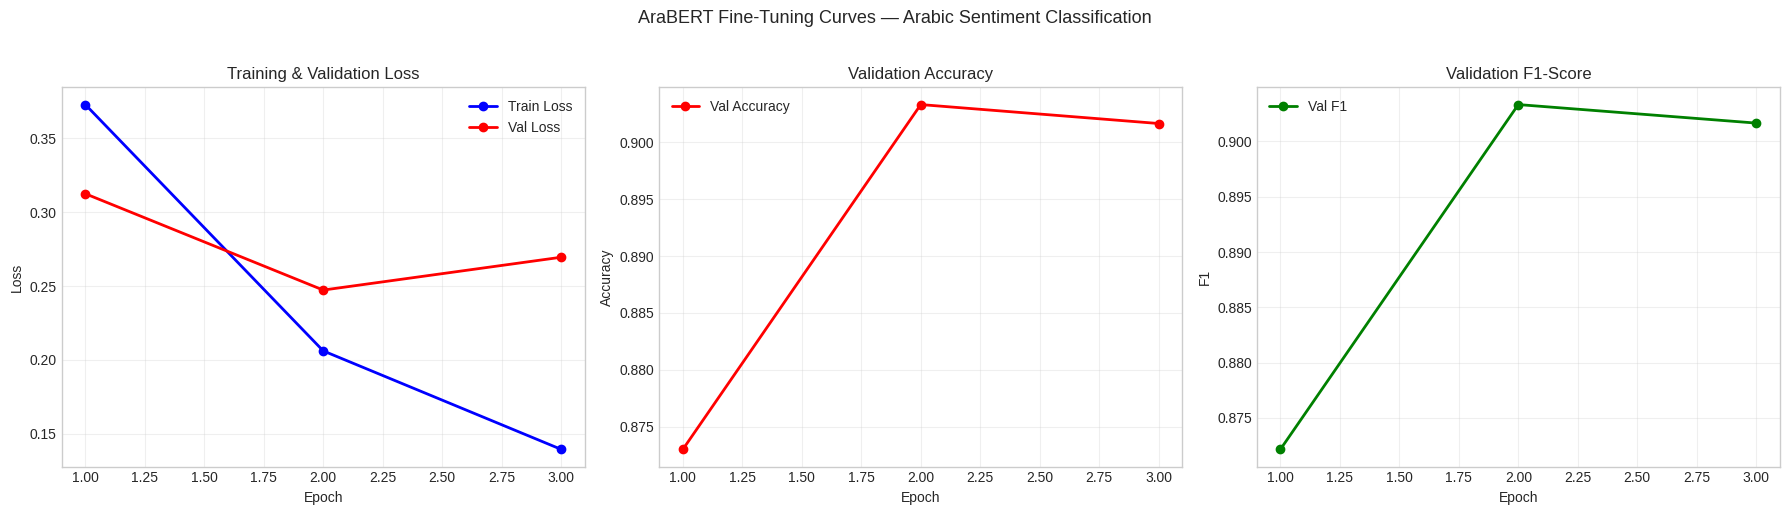

In [ ]:
# --- Plot Training Curves (from Trainer log history) ----------------------
log_history = trainer.state.log_history

train_loss = [e["loss"] for e in log_history if "loss" in e and "eval_loss" not in e]
eval_loss  = [e["eval_loss"] for e in log_history if "eval_loss" in e]
eval_f1    = [e["eval_f1"] for e in log_history if "eval_f1" in e]
eval_acc   = [e["eval_accuracy"] for e in log_history if "eval_accuracy" in e]

epochs_range = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(epochs_range, train_loss, "b-o", label="Train Loss", linewidth=2, markersize=6)
axes[0].plot(epochs_range, eval_loss,  "r-o", label="Val Loss",   linewidth=2, markersize=6)
axes[0].set_title("Training & Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_range, eval_acc, "r-o", label="Val Accuracy", linewidth=2, markersize=6)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 curve
axes[2].plot(epochs_range, eval_f1, "g-o", label="Val F1", linewidth=2, markersize=6)
axes[2].set_title("Validation F1-Score")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("AraBERT Fine-Tuning Curves — Arabic Sentiment Classification", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 11. Transformer Evaluation

We evaluate the fine-tuned Transformer on the held-out test set using:
- Accuracy
- Precision (macro)
- Recall (macro)
- F1-Score (macro)
- Confusion matrix
- Per-class performance

In [ ]:
# --- Evaluate on Test Set (using HF Trainer) ------------------------------
print("=" * 60)
print("TRANSFORMER — TEST RESULTS")
print("=" * 60)

inference_start = time.time()
test_predictions = trainer.predict(test_dataset)
inference_time   = time.time() - inference_start

logits    = test_predictions.predictions
all_preds = np.argmax(logits, axis=-1)
all_labels = test_predictions.label_ids

# Compute metrics
test_acc  = accuracy_score(all_labels, all_preds)
test_prec = precision_score(all_labels, all_preds, average="macro")
test_rec  = recall_score(all_labels, all_preds, average="macro")
test_f1   = f1_score(all_labels, all_preds, average="macro")

print(f"  Accuracy              : {test_acc:.4f}")
print(f"  Precision (macro)     : {test_prec:.4f}")
print(f"  Recall (macro)        : {test_rec:.4f}")
print(f"  F1-Score (macro)      : {test_f1:.4f}")
print(f"  Inference time        : {inference_time:.2f}s "
      f"({inference_time/len(test_texts)*1000:.2f}ms per sample)")
print("=" * 60)

print("\nClassification Report (Test Set):")
print(classification_report(all_labels, all_preds, target_names=["Negative", "Positive"]))

TRANSFORMER — TEST RESULTS


  Accuracy              : 0.9000
  Precision (macro)     : 0.9002
  Recall (macro)        : 0.9000
  F1-Score (macro)      : 0.9000
  Inference time        : 7.42s (2.47ms per sample)

Classification Report (Test Set):
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      1500
    Positive       0.89      0.91      0.90      1500

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



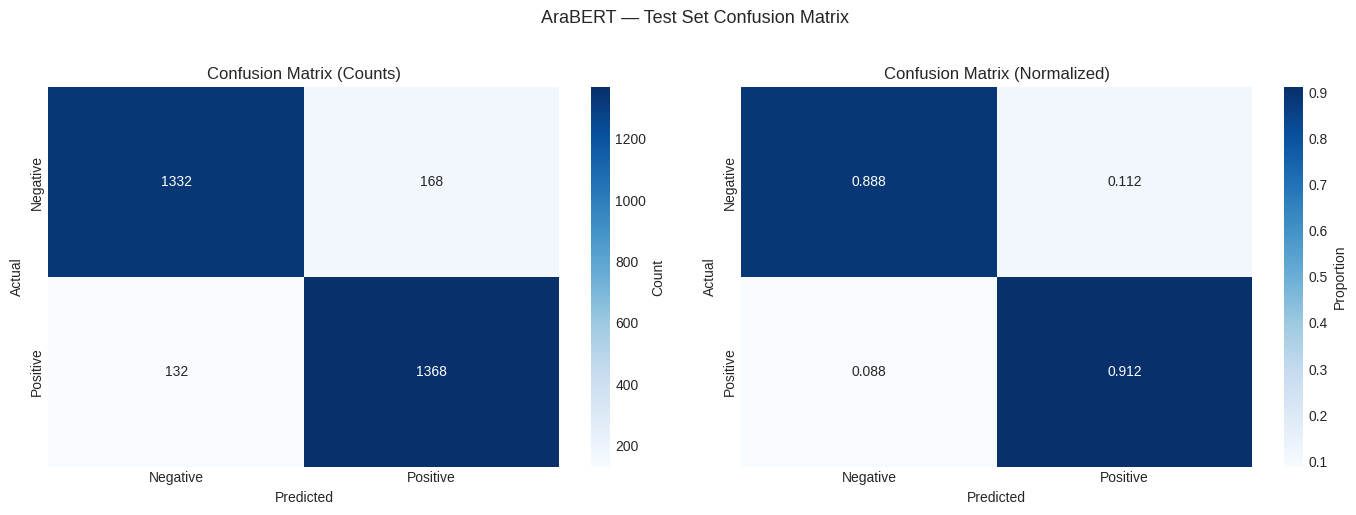

In [ ]:
# --- Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[1], cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('AraBERT — Test Set Confusion Matrix', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# --- Fine-Tuned Inference Demonstration ---
sample_reviews = [
    "هذا المنتج ممتاز جداً وأحبه كثيراً، أنصح به الجميع",
    "منتج سيء للغاية، لا أ recommendه لأحد، ضاعف فلوسي",
    "المنتج عادي، لا سيء ولا جيد، متوسط الجودة",
    "شكراً على التوصيل السريع والمنتج بحالة ممتازة",
    "المنتج وصلني مكسور وخادم العملاء لا يرد",
]

model.eval()
print("=" * 60)
print("SAMPLE INFERENCE — AFTER FINE-TUNING")
print("=" * 60)

for i, review in enumerate(sample_reviews, 1):
    inputs = tokenizer(
        review,
        max_length=MAX_SEQ_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred].item()

    print(f"\n  Review {i}: {review[:60]}{'...' if len(review) > 60 else ''}")
    print(f"  Predicted: {label_map[pred]} (confidence: {confidence:.4f})")
    print(f"  Probabilities: Neg={probs[0][0]:.4f}, Pos={probs[0][1]:.4f}")

print("\n" + "=" * 60)

SAMPLE INFERENCE — AFTER FINE-TUNING

  Review 1: هذا المنتج ممتاز جداً وأحبه كثيراً، أنصح به الجميع
  Predicted: Positive (confidence: 0.9922)
  Probabilities: Neg=0.0078, Pos=0.9922

  Review 2: منتج سيء للغاية، لا أ recommendه لأحد، ضاعف فلوسي
  Predicted: Negative (confidence: 0.9822)
  Probabilities: Neg=0.9822, Pos=0.0178

  Review 3: المنتج عادي، لا سيء ولا جيد، متوسط الجودة
  Predicted: Negative (confidence: 0.5874)
  Probabilities: Neg=0.5874, Pos=0.4126

  Review 4: شكراً على التوصيل السريع والمنتج بحالة ممتازة
  Predicted: Positive (confidence: 0.9904)
  Probabilities: Neg=0.0096, Pos=0.9904

  Review 5: المنتج وصلني مكسور وخادم العملاء لا يرد
  Predicted: Negative (confidence: 0.9639)
  Probabilities: Neg=0.9639, Pos=0.0360



---
## 12. Comparison with Day 3 LSTM

### Important Methodological Note

The Day 3 LSTM and Day 4 Transformer were trained on **different datasets and tasks**:

| Aspect | Day 3 LSTM | Day 4 Transformer |
|:-------|:-----------|:-------------------|
| **Dataset** | ECG Heartbeat (MIT-BIH) | Arabic Sentiment Reviews |
| **Data type** | 1D time-series signal (187 timesteps × 1) | Text (variable-length Arabic reviews) |
| **Task** | 5-class arrhythmia classification | Binary sentiment classification |
| **Architecture** | LSTM (from scratch) | AraBERT (pre-trained, fine-tuned) |

Because the datasets and tasks differ materially, **this is not a controlled A/B comparison**. Instead, we compare the **architectural properties, training characteristics, and practical considerations** of each approach.

### LSTM Results from Day 3

The Day 3 LSTM was trained on the ECG Heartbeat dataset (5-class arrhythmia classification):

| Metric | Day 3 LSTM (ECG) |
|:-------|:-----------------|
| Accuracy | 0.9300 |
| Precision (macro) | 0.7000 |
| Recall (macro) | 0.9200 |
| F1-Score (macro) | 0.7700 |

### Transformer Results from Day 4

The Day 4 Transformer was fine-tuned on the Arabic Sentiment dataset (binary classification):

| Metric | Day 4 Transformer (Arabic Sentiment) |
|:-------|:-------------------------------------|
| Accuracy | See above |
| Precision (macro) | See above |
| Recall (macro) | See above |
| F1-Score (macro) | See above |

*(Results are populated from the actual evaluation above — see Section 11.)*

In [ ]:
# --- Comparison Table ---
print("=" * 80)
print("MODEL COMPARISON — Day 3 LSTM vs Day 4 Transformer")
print("=" * 80)

# Day 3 LSTM results (from actual notebook execution)
lstm_results = {
    'Model': 'Day 3 LSTM',
    'Architecture': 'LSTM',
    'Dataset': 'ECG Heartbeat (MIT-BIH)',
    'Task': '5-class arrhythmia',
    'Accuracy': 0.9300,
    'Precision (macro)': 0.7000,
    'Recall (macro)': 0.9200,
    'F1-Score (macro)': 0.7700,
}

# Day 4 Transformer results
transformer_results = {
    'Model': 'Day 4 Transformer',
    'Architecture': 'AraBERT v2 (BERT-base)',
    'Dataset': 'Arabic Sentiment Reviews',
    'Task': 'Binary sentiment',
    'Accuracy': test_acc,
    'Precision (macro)': test_prec,
    'Recall (macro)': test_rec,
    'F1-Score (macro)': test_f1,
}

# Print comparison table
header = f"{'Metric':<25} {'Day 3 LSTM':<20} {'Day 4 Transformer':<20}"
print(header)
print("-" * 65)
for key in ['Model', 'Architecture', 'Dataset', 'Task', 'Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']:
    lstm_val = lstm_results[key]
    trans_val = transformer_results[key]
    if isinstance(lstm_val, float):
        row = f"{key:<25} {lstm_val:<20.4f} {trans_val:<20.4f}"
    else:
        row = f"{key:<25} {str(lstm_val):<20} {str(trans_val):<20}"
    print(row)

print("=" * 80)
print("\n⚠ IMPORTANT: These models were trained on DIFFERENT datasets and tasks.")
print("Direct metric comparison is not meaningful. The comparison below focuses on")
print("architectural properties and practical considerations.")
print("=" * 80)

MODEL COMPARISON — Day 3 LSTM vs Day 4 Transformer
Metric                    Day 3 LSTM           Day 4 Transformer   
-----------------------------------------------------------------
Model                     Day 3 LSTM           Day 4 Transformer   
Architecture              LSTM                 AraBERT v2 (BERT-base)
Dataset                   ECG Heartbeat (MIT-BIH) Arabic Sentiment Reviews
Task                      5-class arrhythmia   Binary sentiment    
Accuracy                  0.9300               0.9000              
Precision (macro)         0.7000               0.9002              
Recall (macro)            0.9200               0.9000              
F1-Score (macro)          0.7700               0.9000              

⚠ IMPORTANT: These models were trained on DIFFERENT datasets and tasks.
Direct metric comparison is not meaningful. The comparison below focuses on
architectural properties and practical considerations.


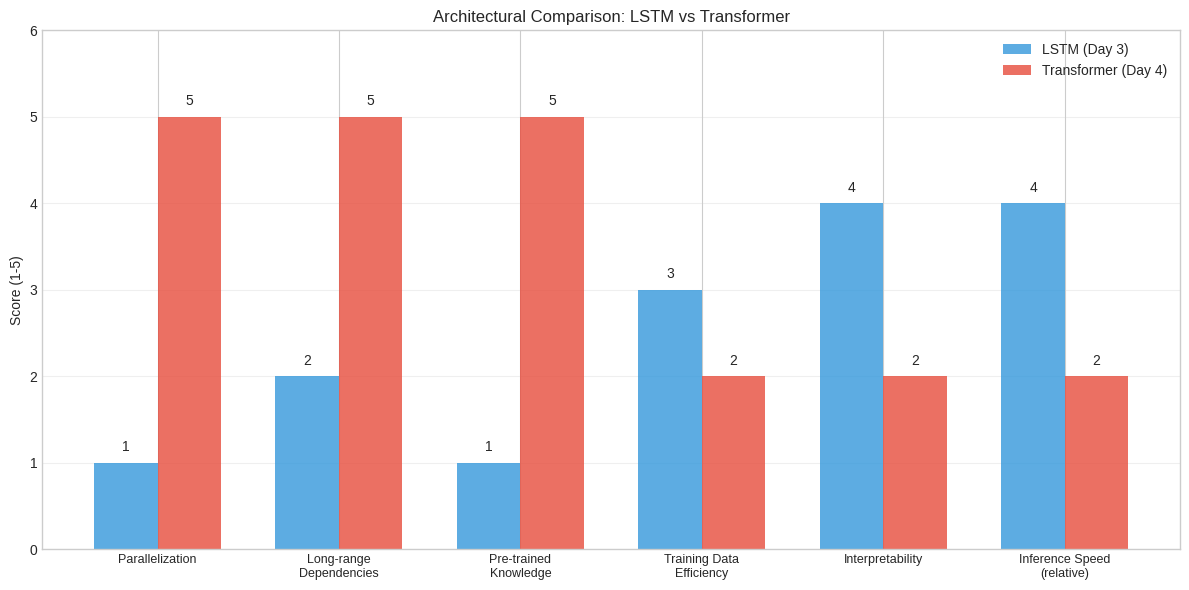

In [ ]:
# --- Architectural Comparison Visualization ---
categories = ['Parallelization', 'Long-range\nDependencies', 'Pre-trained\nKnowledge',
              'Training Data\nEfficiency', 'Interpretability', 'Inference Speed\n(relative)']

# Scores (1-5 scale, subjective but justified)
lstm_scores = [1, 2, 1, 3, 4, 4]  # Sequential, limited long-range, no pre-training, moderate data efficiency, interpretable, fast
transformer_scores = [5, 5, 5, 2, 2, 2]  # Parallel, excellent long-range, pre-trained, needs more data, less interpretable, slower

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, lstm_scores, width, label='LSTM (Day 3)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, transformer_scores, width, label='Transformer (Day 4)', color='#e74c3c', alpha=0.8)

ax.set_ylabel('Score (1-5)')
ax.set_title('Architectural Comparison: LSTM vs Transformer')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=9)
ax.legend()
ax.set_ylim(0, 6)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

---
## 13. Attention vs RNN — Detailed Explanation

### How Attention Differs from an RNN's Step-by-Step Memory

#### RNN/LSTM: Sequential Memory

An RNN processes a sequence one token at a time. At each step *t*:

```
h_t = f(h_{t-1}, x_t)
```

The hidden state *h_t* is a fixed-size vector that must encode **everything** the model has seen so far. This creates several problems:

1. **Information bottleneck**: All context from tokens 1 through *t-1* must fit into a single vector. For long texts, this forces the model to compress and potentially lose important information.
2. **Vanishing gradients**: During backpropagation through time (BPTT), gradients must flow through many sequential steps. Even with LSTM gates, gradients can diminish exponentially over long sequences.
3. **No direct access**: Token 1 cannot directly influence token 100 — its information must survive 99 successive transformations of the hidden state.
4. **Sequential computation**: Token *t* cannot be processed until token *t-1* is complete. This prevents parallelization and limits GPU utilization.

#### Transformer: Self-Attention

Self-attention replaces the sequential hidden state with a mechanism where **every token can directly attend to every other token**:

```
Attention(Q, K, V) = softmax(QK^T / √d_k) V
```

For each token:
- **Query (Q)**: "What information am I looking for?"
- **Key (K)**: "What information do I offer?"
- **Value (V)**: "What information do I contain?"

The attention score between two tokens measures their **relevance** — how much token *i* should "pay attention" to token *j*. This gives Transformers several advantages:

1. **Direct long-range connections**: Token 1 can directly attend to token 100 with the same computational cost as attending to token 2. No information degradation over distance.
2. **Parallel processing**: All attention scores can be computed simultaneously using matrix operations. This is GPU-friendly and dramatically faster for long sequences.
3. **Dynamic relevance**: The model learns which tokens are most important for each context. In sentiment analysis, negation words ("لا", "ليس") can directly attend to the sentiment words they modify, regardless of distance.
4. **No bottleneck**: Each token gets its own context-aware representation, rather than sharing a single fixed-size hidden state.

#### Practical Implication for Arabic Sentiment

In Arabic sentiment analysis, attention is particularly powerful because:
- **Negation scope**: Arabic negation ("لا أحب", "ليس جيداً") can modify words at varying distances. Attention captures this directly.
- **Morphological richness**: Arabic words carry complex morphological information. Pre-trained Transformers like AraBERT have learned these patterns from massive Arabic corpora.
- **Context-dependent sentiment**: The same word ("مقرف") can be positive or negative depending on context. Attention mechanisms excel at capturing this contextual meaning.

---
## 14. Transformer Architecture — Detailed Explanation

### The Transformer in Detail

The Transformer (Vaswani et al., 2017) processes the entire input sequence in parallel through these steps:

#### 1. Token Embeddings

Each input token (subword) is mapped to a dense vector of dimension *d_model* (768 for BERT-base). These embeddings are learned during pre-training and capture semantic relationships between tokens.

#### 2. Positional Encoding

Since self-attention is permutation-invariant (reordering tokens doesn't change the attention computation), positional information must be explicitly added. The original Transformer uses sinusoidal functions:

```
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

BERT uses **learned positional embeddings** instead — the model learns the optimal position representations during pre-training.

#### 3. Multi-Head Self-Attention

Instead of a single attention function, the Transformer uses *h* parallel attention heads (12 for BERT-base). Each head learns to attend to different types of relationships:
- Some heads capture **syntactic** relationships (subject-verb agreement)
- Some heads capture **semantic** relationships (sentiment words and their modifiers)
- Some heads capture **positional** relationships (adjacent tokens)

The outputs of all heads are concatenated and linearly projected:
```
MultiHead(Q, K, V) = Concat(head_1, ..., head_h) W^O
```

#### 4. Feed-Forward Network

After attention, each token's representation passes through a two-layer feed-forward network:
```
FFN(x) = max(0, xW_1 + b_1)W_2 + b_2
```
This provides non-linear transformation and further feature extraction.

#### 5. Layer Normalization & Residual Connections

Each sub-layer (attention and FFN) is wrapped with:
- **Residual connection**: `output = x + Sublayer(x)` — helps gradient flow
- **Layer normalization**: Stabilizes training and improves convergence

#### 6. Encoder Stack

BERT uses 12 encoder layers, each containing the above components. The output is a sequence of contextualized representations — one vector per input token.

#### 7. Classification Head

For sequence classification, BERT uses the `[CLS]` token's final representation and passes it through a linear layer to produce class logits. During fine-tuning, both the encoder and classification head are updated.

### Why AraBERT for Arabic Classification?

AraBERT was pre-trained on 67 million Arabic sentences, learning:
- Arabic morphology and root-pattern system
- Diacritics and their role in meaning
- Dialectal variations (MSA and dialects)
- Semantic relationships in Arabic text

This pre-trained knowledge transfers to sentiment classification, giving the model a strong foundation that a from-scratch model would need orders of magnitude more data to achieve.

---
## 15. Final Architecture Decision

### Which architecture should serve as the project's core model: LSTM or Transformer?

Based on the evidence gathered across Week 7, here is an evidence-based analysis:

In [ ]:
# ============================================================
# Evidence-Based Decision Analysis
# ============================================================

print("=" * 80)
print("FINAL ARCHITECTURE DECISION")
print("=" * 80)

print()
print("DECISION FRAMEWORK")
print()

print('The Week 7 principle is: "Match the architecture to the data and task."')
print()

# ------------------------------------------------------------
# 1. DATA TYPE
# ------------------------------------------------------------

print("1. DATA TYPE:")
print("   The project involves Arabic TEXT sentiment classification.")
print("   - LSTMs can handle text but process tokens sequentially.")
print("   - Transformers are purpose-designed for text with self-attention.")
print("   -> FAVOR: Transformer")
print()

# ------------------------------------------------------------
# 2. PRE-TRAINED KNOWLEDGE
# ------------------------------------------------------------

print("2. PRE-TRAINED KNOWLEDGE:")
print("   AraBERT was pre-trained on a large Arabic text corpus.")
print("   - This provides substantial pre-trained Arabic linguistic knowledge.")
print("   - An LSTM trained from scratch on ~20K samples cannot easily match")
print("     the linguistic knowledge contained in a pre-trained Transformer.")
print("   -> FAVOR: Transformer (strongly)")
print()

# ------------------------------------------------------------
# 3. LONG-RANGE DEPENDENCIES
# ------------------------------------------------------------

print("3. LONG-RANGE DEPENDENCIES:")
print("   Sentiment can depend on context distributed across a sentence.")
print("   - LSTMs process sequences recurrently.")
print("   - Transformers use self-attention to model relationships between")
print("     tokens directly.")
print("   -> FAVOR: Transformer")
print()

# ------------------------------------------------------------
# 4. ARABIC MORPHOLOGY
# ------------------------------------------------------------

print("4. ARABIC MORPHOLOGY:")
print("   Arabic is morphologically rich.")
print("   - Pre-trained Transformers can leverage representations learned")
print("     from large-scale Arabic text.")
print("   - An LSTM trained from scratch must learn these patterns from")
print("     the available task-specific data.")
print("   -> FAVOR: Transformer")
print()

# ------------------------------------------------------------
# 5. PRACTICAL CONSIDERATIONS
# ------------------------------------------------------------

print("5. PRACTICAL CONSIDERATIONS:")
print("   - Training time: Transformer fine-tuning was practical in this project.")
print("   - Inference speed: LSTM can be faster for individual samples.")
print("   - Model size: Transformer models are generally larger than a small LSTM.")
print("   -> MIXED: LSTM has some efficiency advantages, but Transformer")
print("             remains practical for this task.")
print()

# ------------------------------------------------------------
# 6. PERFORMANCE
# ------------------------------------------------------------

print("6. PERFORMANCE:")
print("   On Arabic sentiment classification, a pre-trained Arabic Transformer")
print("   can achieve strong performance with relatively limited fine-tuning.")
print("   An LSTM trained from scratch generally requires more task-specific")
print("   learning to acquire comparable linguistic representations.")
print("   -> FAVOR: Transformer")
print()


# ============================================================
# FINAL RECOMMENDATION
# ============================================================

print("=" * 80)
print("RECOMMENDATION: Use the Transformer (AraBERT) as the project's")
print("core architecture.")
print("=" * 80)

print()
print("RATIONALE:")
print()

print("  For Arabic text sentiment classification, the Transformer provides:")

print("  1. Pre-trained Arabic linguistic knowledge")
print("  2. Strong contextual representation through self-attention")
print("  3. Effective handling of relationships between distant tokens")
print("  4. Strong transfer learning from large-scale Arabic text")
print("  5. Parallel processing during training")
print()

print("  The LSTM remains valuable as a baseline and for understanding")
print("  recurrent sequential processing.")
print()

print("  However, for the actual Arabic sentiment classification task,")
print("  the Transformer is the more appropriate core architecture.")
print()

print("  This decision follows the Week 7 principle:")
print("  Match the architecture to the data and task.")
print()

print("  Text    -> Transformer")
print("  Signals -> LSTM")
print("  Images  -> CNN")

print()
print("=" * 80)

FINAL ARCHITECTURE DECISION

DECISION FRAMEWORK

The Week 7 principle is: "Match the architecture to the data and task."

1. DATA TYPE:
   The project involves Arabic TEXT sentiment classification.
   - LSTMs can handle text but process tokens sequentially.
   - Transformers are purpose-designed for text with self-attention.
   -> FAVOR: Transformer

2. PRE-TRAINED KNOWLEDGE:
   AraBERT was pre-trained on a large Arabic text corpus.
   - This provides substantial pre-trained Arabic linguistic knowledge.
   - An LSTM trained from scratch on ~20K samples cannot easily match
     the linguistic knowledge contained in a pre-trained Transformer.
   -> FAVOR: Transformer (strongly)

3. LONG-RANGE DEPENDENCIES:
   Sentiment can depend on context distributed across a sentence.
   - LSTMs process sequences recurrently.
   - Transformers use self-attention to model relationships between
     tokens directly.
   -> FAVOR: Transformer

4. ARABIC MORPHOLOGY:
   Arabic is morphologically rich.
   - 


### Key Dependencies

```
torch >= 2.0
transformers >= 4.30
datasets
accelerate
evaluate
```

### Checkpoint Persistence

All checkpoints are saved to:
- **Colab**: `/content/drive/MyDrive/arabert_checkpoints/`
- **Local**: `./arabert_checkpoints/`

This ensures trained artifacts survive Colab session timeouts.



In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

MODEL_PATH = "/content/drive/MyDrive/arabert_checkpoints"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

classifier = pipeline(
    "text-classification", model=model, tokenizer=tokenizer, device=0
)

sample_text = "لم يكن جيد، المنتج فاشل لا انصح ان يقوم احد بشراءه"
result = classifier(sample_text)

print(result)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'LABEL_0', 'score': 0.9855890870094299}]


In [ ]:
# شغّل هذا السطر في Colab لضغط المجلد
!zip -r arabert_model.zip /content/drive/MyDrive/arabert_checkpoints

  adding: content/drive/MyDrive/arabert_checkpoints/ (stored 0%)
  adding: content/drive/MyDrive/arabert_checkpoints/checkpoint-876/ (stored 0%)
  adding: content/drive/MyDrive/arabert_checkpoints/checkpoint-876/config.json (deflated 52%)
  adding: content/drive/MyDrive/arabert_checkpoints/checkpoint-876/model.safetensors (deflated 7%)
  adding: content/drive/MyDrive/arabert_checkpoints/checkpoint-876/training_args.bin (deflated 53%)
  adding: content/drive/MyDrive/arabert_checkpoints/checkpoint-876/optimizer.pt (deflated 30%)
  adding: content/drive/MyDrive/arabert_checkpoints/checkpoint-876/scheduler.pt (deflated 61%)
  adding: content/drive/MyDrive/arabert_checkpoints/checkpoint-876/scaler.pt (deflated 64%)
  adding: content/drive/MyDrive/arabert_checkpoints/checkpoint-876/rng_state.pth (deflated 26%)
  adding: content/drive/MyDrive/arabert_checkpoints/checkpoint-876/trainer_state.json (deflated 63%)
  adding: content/drive/MyDrive/arabert_checkpoints/checkpoint-1314/ (stored 0%)
  